# Ultra-Lightweight and Interpretable Intrusion Detection in Software-Defined Networking: A Consensus XAI-Driven Feature Reduction Framework

Author: Mohammad Javad Akbari  
Objective: Implement a Zero-Leakage NIDS pipeline utilizing Dual-XAI (SHAP + LIME) to calculate a Jaccard Consensus and dynamic 95% variance elbow cutoff, thereby minimizing SDN controller-plane latency. 

## Abstract
Modern network architectures increasingly rely on Software-Defined Networking (SDN) to decouple the control logic from data forwarding planes. However, this centralization introduces severe security risks. Existing NIDS paradigms frequently deploy heavy Deep Learning (DL) architectures that induce high computational overhead and unacceptable latency. This notebook implements an ultra-lightweight, high-throughput, and fully interpretable NIDS pipeline. By leveraging a Dual-XAI (SHAP + LIME) consensus mechanism for dimensionality reduction, we systematically eliminate non-informative flow features and deploy classical machine learning classifiers directly optimized for resource-constrained SDN controller environments.

## References
[1] A. H. Janabi, T. Kanakis, M. Johnson, "Survey: Intrusion Detection System in Software-Defined Networking," IEEE Access, 2024. DOI: 10.1109/ACCESS.2024.3493384  
[2] M. S. Elsayed, N.-A. Le-Khac, A. D. Jurcut, "InSDN: A Novel SDN Intrusion Dataset," IEEE Access, 2020. DOI: 10.1109/ACCESS.2020.3022633  
[3] M. Tserenkhuu, M. D. Hossain, Y. Taenaka, Y. Kadobayashi, "Intrusion Detection System Framework for SDN-Based IoT Networks Using Deep Learning Approaches With XAI-Based Feature Selection Techniques and Domain-Constrained Features," IEEE Access, 2025. DOI: 10.1109/ACCESS.2025.3595595  
[4] M. T. Ribeiro, S. Singh, C. Guestrin, "Why Should I Trust You? Explaining the Predictions of Any Classifier," Proc. 22nd ACM SIGKDD, 2016. DOI: 10.1145/2939672.2939778  
[5] S. M. Lundberg, S.-I. Lee, "A Unified Approach to Interpreting Model Predictions," NeurIPS (NIPS), 2017.  
[6] I. Sharafaldin, A. H. Lashkari, A. A. Ghorbani, "Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization (CSE-CIC-IDS2018)," ICISSP, 2018. DOI: 10.5220/0006639801080116  
[7] A. Mohamed, "Cleaned CSE-CIC-IDS2018 Dataset," Mendeley Data, V1, 2024. DOI: 10.17632/29hdbdzx2r.1  
[8] F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," JMLR, vol. 12, 2011.  
[9] G. Ke et al., "LightGBM: A Highly Efficient Gradient Boosting Decision Tree," NeurIPS, vol. 30, 2017.  
[10] T. Chen, C. Guestrin, "XGBoost: A Scalable Tree Boosting System," Proc. 22nd ACM SIGKDD, 2016. DOI: 10.1145/2939672.2939785"

## 2. Setup & Global Configuration
Initialize the computational environment, declare deterministic seeds, and configure structural limits for memory safety.

In [1]:
import os
import gc
import time
import psutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import xgboost as xgb
import lightgbm as lgb
import shap
import lime.lime_tabular
import optuna
import joblib

# Attempt PyTorch import for CNN baseline; degrade gracefully if unavailable
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not found. CNN baseline will be skipped. MLP will serve as DL baseline.")

warnings.filterwarnings('ignore')

# Central Configuration Dictionary
CONFIG = {
    'INSDN_PATH': Path('./datasets/InSDN_Normal_and_Attack_Combined.csv'),
    'CIC_PATH': Path('./datasets/CSE-CIC-IDS2018/'),
    'ARTIFACTS_DIR': Path('./artifacts/'),
    'MODELS_DIR': Path('./artifacts/models/'),
    'FIGURES_DIR': Path('./artifacts/figures/'),
    'RANDOM_STATE': 42,
    'MAX_ROWS_PER_CLASS': 50000,
    'CHUNKSIZE': 100000
}

# Ensure structural directories exist
for path in [CONFIG['ARTIFACTS_DIR'], CONFIG['MODELS_DIR'], CONFIG['FIGURES_DIR']]:
    path.mkdir(parents=True, exist_ok=True)

# Enforce Determinism
np.random.seed(CONFIG['RANDOM_STATE'])
if TORCH_AVAILABLE:
    torch.manual_seed(CONFIG['RANDOM_STATE'])

## 3. Data Ingestion & Leakage-Free Preprocessing (Phase A)
Robust, chunked data loading with immediate dtype downcasting to respect hardware constraints (16GB RAM limit). Adheres to a strict 70/15/15 train/val/test split.

In [2]:
def memory_usage():
    """Returns current process memory usage in MB."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)

def clean_and_downcast(df):
    """Removes identifiers, handles NaNs, and downcasts numerical types."""
    identifiers = ['Flow ID', 'Source IP', 'Src IP', 'Destination IP', 'Dst IP', 
                   'Source Port', 'Src Port', 'Destination Port', 'Dst Port', 
                   'Timestamp', 'Protocol']
    cols_to_drop = [c for c in identifiers if c in df.columns]
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)
    
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

def generate_synthetic_fallback():
    """Generates a mock dataset if the physical datasets are absent, ensuring script viability."""
    print("WARNING: Dataset paths not found. Generating synthetic empirical distribution to ensure script execution.")
    from sklearn.datasets import make_classification
    X, y = make_classification(n_samples=20000, n_features=75, n_informative=20, n_redundant=10, 
                               n_classes=3, weights=[0.6, 0.3, 0.1], random_state=CONFIG['RANDOM_STATE'])
    feature_names = [f'Flow_Feature_{i}' for i in range(75)]
    df = pd.DataFrame(X, columns=feature_names)
    df['Label'] = np.where(y == 0, 'Normal', np.where(y == 1, 'Attack_A', 'Attack_B'))
    return df

def ingest_data():
    """Loads data from disk if available, applying chunking and stratified capping."""
    dfs = []
    files_processed = 0
    
    # 1. Load InSDN
    if CONFIG['INSDN_PATH'].exists():
        print("Loading InSDN...")
        df_insdn = pd.read_csv(CONFIG['INSDN_PATH'])
        df_insdn = clean_and_downcast(df_insdn)
        dfs.append(df_insdn)
        files_processed += 1
        
    # 2. Load CSE-CIC-IDS2018 (Iterative Chunking)
    if CONFIG['CIC_PATH'].exists() and CONFIG['CIC_PATH'].is_dir():
        print("Loading CSE-CIC-IDS2018...")
        for file in CONFIG['CIC_PATH'].glob('*.csv'):
            for chunk in pd.read_csv(file, chunksize=CONFIG['CHUNKSIZE']):
                chunk = clean_and_downcast(chunk)
                dfs.append(chunk)
                break  # For demonstration/memory safety, limit to 1 chunk per file
            files_processed += 1
            
    if files_processed == 0:
        return generate_synthetic_fallback()
        
    combined_df = pd.concat(dfs, ignore_index=True)
    del dfs
    gc.collect()
    
    # Enforce Class Capping
    if 'Label' in combined_df.columns:
        combined_df = combined_df.groupby('Label').apply(
            lambda x: x.sample(min(len(x), CONFIG['MAX_ROWS_PER_CLASS']), random_state=CONFIG['RANDOM_STATE'])
        ).reset_index(drop=True)
        
    return combined_df

# Execute Data Loading Pipeline
print(f"Initial Memory: {memory_usage():.2f} MB")
data = ingest_data()
print(f"Post-Load Memory: {memory_usage():.2f} MB")

# Standardize label column name to 'Label'
label_col = 'Label' if 'Label' in data.columns else data.columns[-1]
X = data.drop(columns=[label_col])
y = data[label_col]

# Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Strict 70/15/15 Stratified Split (Zero-Leakage)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_encoded, test_size=0.15, stratify=y_encoded, random_state=CONFIG['RANDOM_STATE'])
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, stratify=y_train_val, random_state=CONFIG['RANDOM_STATE']
) # 0.1765 of 0.85 is ~0.15 of total

# Fit Scaler ONLY on Training Split
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print(f"Train shape: {X_train_scaled.shape}, Val shape: {X_val_scaled.shape}, Test shape: {X_test_scaled.shape}")

Initial Memory: 398.85 MB
Loading InSDN...
Loading CSE-CIC-IDS2018...
Post-Load Memory: 529.80 MB
Train shape: (273139, 76), Val shape: (58542, 76), Test shape: (58533, 76)


## 4. Baseline Evaluation (Full Feature Set)
Compute empirical benchmarks using all raw features to map baseline Deep Learning performance versus Classical ML models.

In [3]:
baseline_metrics = []
global_baseline_models = {}  # Store references for final multi-stage analysis

def evaluate_model(name, model, X_t, y_t, X_v, y_v):
    print(f"Training {name} (Full Features)...")
    start_train = time.time()
    
    if name == '1D CNN (PyTorch)':
        X_tensor = torch.tensor(X_t.values, dtype=torch.float32)
        y_tensor = torch.tensor(y_t, dtype=torch.long)
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=256, shuffle=True)
        
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        model.train()
        for epoch in range(5):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                out = model(batch_X.unsqueeze(1))
                loss = criterion(out, batch_y)
                loss.backward()
                optimizer.step()
    else:
        model.fit(X_t, y_t)
        
    train_time = time.time() - start_train
    
    start_infer = time.perf_counter()
    if name == '1D CNN (PyTorch)':
        model.eval()
        with torch.no_grad():
            preds_tensor = model(torch.tensor(X_v.values, dtype=torch.float32).unsqueeze(1))
            preds = torch.argmax(preds_tensor, dim=1).numpy()
    else:
        preds = model.predict(X_v)
    infer_time = time.perf_counter() - start_infer
    
    latency_us = (infer_time / len(X_v)) * 1e6
    acc = accuracy_score(y_v, preds)
    f1 = f1_score(y_v, preds, average='macro')
    
    baseline_metrics.append({
        'Model': name,
        'Phase': 'Full Features',
        'Train Time (s)': round(train_time, 2),
        'Latency/Sample (µs)': round(latency_us, 2),
        'Accuracy': round(acc, 4),
        'Macro-F1': round(f1, 4),
        'RAM (MB)': round(memory_usage(), 2)
    })
    global_baseline_models[name] = model

num_classes = len(np.unique(y_train))
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=CONFIG['RANDOM_STATE']),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1, random_state=CONFIG['RANDOM_STATE']),
    'LightGBM': lgb.LGBMClassifier(random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbosity=-1),
    'MLP (DL Baseline)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=20, random_state=CONFIG['RANDOM_STATE'])
}

if TORCH_AVAILABLE:
    class Simple1DCNN(nn.Module):
        def __init__(self, num_features, num_classes):
            super(Simple1DCNN, self).__init__()
            self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
            self.relu = nn.ReLU()
            self.pool = nn.MaxPool1d(kernel_size=2)
            self.flatten = nn.Flatten()
            self.fc1 = nn.Linear(16 * (num_features // 2), 32)
            self.fc2 = nn.Linear(32, num_classes)
            
        def forward(self, x):
            x = self.pool(self.relu(self.conv1(x)))
            x = self.flatten(x)
            x = self.relu(self.fc1(x))
            x = self.fc2(x)
            return x
            
    models['1D CNN (PyTorch)'] = Simple1DCNN(X_train_scaled.shape[1], num_classes)

for name, clf in models.items():
    evaluate_model(name, clf, X_train_scaled, y_train, X_val_scaled, y_val)
    gc.collect()

baseline_df = pd.DataFrame(baseline_metrics)
print("\n--- Baseline Model Performance (Full Features) ---")
display(baseline_df)

Training Decision Tree (Full Features)...
Training Random Forest (Full Features)...
Training XGBoost (Full Features)...
Training LightGBM (Full Features)...
Training MLP (DL Baseline) (Full Features)...
Training 1D CNN (PyTorch) (Full Features)...

--- Baseline Model Performance (Full Features) ---


,Model,Phase,Train Time (s),Latency/Sample (µs),Accuracy,Macro-F1,RAM (MB)
0,Decision Tree,Full Features,6.62,0.40,0.9980,0.9016,1102.08
1,Random Forest,Full Features,4.57,1.94,0.9980,0.8997,1116.68
2,XGBoost,Full Features,17.23,2.42,0.9984,0.8875,1125.73
3,LightGBM,Full Features,10.61,5.59,0.2452,0.0958,1120.45
4,MLP (DL Baseline),Full Features,22.34,0.84,0.9960,0.8103,1157.88
5,1D CNN (PyTorch),Full Features,26.40,3.42,0.9907,0.7665,1347.39


## 5. Dual-XAI Consensus & Dynamic Reduction (Phase B)
Train an ultra-fast proxy explainer (LightGBM) to execute global SHAP evaluation and local LIME aggregation. Utilize the Jaccard Similarity index for validation and the 95% Cumulative Variance Threshold to isolate the optimal subspace dimension.

In [4]:
print("Training proxy LightGBM for XAI Interpretation...")
proxy_model = lgb.LGBMClassifier(n_estimators=50, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbosity=-1)
proxy_model.fit(X_train_scaled, y_train)

print("Executing Global SHAP extraction...")
explainer_shap = shap.TreeExplainer(proxy_model)
X_train_sample = shap.sample(X_train_scaled, 5000, random_state=CONFIG['RANDOM_STATE'])
shap_output = explainer_shap(X_train_sample)

if hasattr(shap_output, "values"):
    shap_values = shap_output.values
else:
    shap_values = shap_output

if len(shap_values.shape) == 3:
    shap_importance = np.abs(shap_values).mean(axis=(0, 2))
elif isinstance(shap_values, list):
    shap_importance = np.abs(np.array(shap_values)).mean(axis=(0, 1))
else:
    shap_importance = np.abs(shap_values).mean(axis=0)

shap_ranked = pd.Series(shap_importance, index=X_train_scaled.columns).sort_values(ascending=False)

print("Executing Local LIME Aggregation...")
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values, 
    feature_names=X_train_scaled.columns.tolist(), 
    class_names=[str(c) for c in le.classes_],
    mode='classification',
    random_state=CONFIG['RANDOM_STATE']
)

lime_importance = {col: 0.0 for col in X_train_scaled.columns}
sample_size = 100
for i in range(sample_size):
    exp = explainer_lime.explain_instance(X_train_sample.iloc[i].values, proxy_model.predict_proba, num_features=20)
    for feature, weight in exp.as_list():
        for col in X_train_scaled.columns:
            if col in feature:
                lime_importance[col] += abs(weight)
                break

lime_ranked = pd.Series(lime_importance).sort_values(ascending=False)

print("\n--- Jaccard Similarity Calculation ---")
top_20_shap = set(shap_ranked.head(20).index)
top_20_lime = set(lime_ranked.head(20).index)
intersection = top_20_shap.intersection(top_20_lime)
union = top_20_shap.union(top_20_lime)
jaccard_index = len(intersection) / len(union)
print(f"Jaccard Similarity (Top 20 Features): {jaccard_index:.4f}")

print("\n--- Dynamic Elbow Thresholding (95% Variance) ---")
shap_norm = shap_importance / np.sum(shap_importance)
lime_weights = np.array([lime_importance[c] for c in X_train_scaled.columns])
lime_norm = lime_weights / (np.sum(lime_weights) + 1e-9)

consensus_importance = (shap_norm + lime_norm) / 2
consensus_series = pd.Series(consensus_importance, index=X_train_scaled.columns).sort_values(ascending=False)

cumulative_variance = consensus_series.cumsum()
optimal_k = (cumulative_variance >= 0.95).idxmax()
k_index = consensus_series.index.get_loc(optimal_k) + 1

print(f"Optimal Dimensions Retained for 95% Variance: {k_index} features (out of {len(X_train_scaled.columns)})")

selected_features = consensus_series.head(k_index).index.tolist()

X_train_red = X_train_scaled[selected_features]
X_val_red = X_val_scaled[selected_features]
X_test_red = X_test_scaled[selected_features]

print(f"Reduced Training Space Shape: {X_train_red.shape}")

Training proxy LightGBM for XAI Interpretation...
Executing Global SHAP extraction...
Executing Local LIME Aggregation...

--- Jaccard Similarity Calculation ---
Jaccard Similarity (Top 20 Features): 0.2500

--- Dynamic Elbow Thresholding (95% Variance) ---
Optimal Dimensions Retained for 95% Variance: 48 features (out of 76)
Reduced Training Space Shape: (273139, 48)


## 6. Hyperparameter Tuning & Reduced Feature Training (Phase C)
Apply Bayesian Optimization (Optuna) exclusively over the lightweight algorithms (XGBoost, LightGBM) utilizing the structurally reduced dimensionality.

In [5]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': CONFIG['RANDOM_STATE'],
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',
        'n_jobs': -1
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_red, y_train)
    preds = model.predict(X_val_red)
    return f1_score(y_val, preds, average='macro')

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'random_state': CONFIG['RANDOM_STATE'],
        'n_jobs': -1
    }
    model = lgb.LGBMClassifier(**params, verbosity=-1)
    model.fit(X_train_red, y_train)
    preds = model.predict(X_val_red)
    return f1_score(y_val, preds, average='macro')

print("Starting Optuna Optimization (N_TRIALS=10) to respect execution constraints...")
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=10)
print(f"Best XGBoost F1: {study_xgb.best_value:.4f}")

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=10)
print(f"Best LightGBM F1: {study_lgb.best_value:.4f}")

# Train Final Optimized Models
xgb_tuned = xgb.XGBClassifier(**study_xgb.best_params, random_state=CONFIG['RANDOM_STATE'], use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
lgb_tuned = lgb.LGBMClassifier(**study_lgb.best_params, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1, verbosity=-1)
rf_reduced = RandomForestClassifier(n_estimators=50, random_state=CONFIG['RANDOM_STATE'], n_jobs=-1)
dt_reduced = DecisionTreeClassifier(random_state=CONFIG['RANDOM_STATE'])

tuned_models = {
    'Decision Tree': dt_reduced,
    'Random Forest': rf_reduced,
    'XGBoost (Tuned)': xgb_tuned,
    'LightGBM (Tuned)': lgb_tuned
}

for name, model in tuned_models.items():
    model.fit(X_train_red, y_train)
    joblib.dump(model, CONFIG['MODELS_DIR'] / f"{name.replace(' ', '_')}_reduced.pkl")

print("Optimized reduced models successfully trained and serialized to disk.")

Starting Optuna Optimization (N_TRIALS=10) to respect execution constraints...
Best XGBoost F1: 0.9102
Best LightGBM F1: 0.8795
Optimized reduced models successfully trained and serialized to disk.


## 7. Final Test Evaluation & Hardware-Constrained Micro-Benchmarking (Phase D)
Stress-test the NIDS utilizing the held-out test split, isolating throughput boundaries (Packets Per Second) and latency distributions to validate deployment viability on an SDN Edge Controller.

Initiating strictly isolated benchmarking against Test Split...

--- Final Model Performance & Benchmarks (With DL Baselines Included) ---


,Model,Phase,Latency/Sample (µs),Throughput (PPS),Accuracy,Macro-F1,Model Size (KB)
0,Decision Tree,Reduced (Consensus XAI),0.41,2432378,0.9984,0.9329,214.8
1,Random Forest,Reduced (Consensus XAI),1.73,578576,0.9984,0.9306,13165.2
2,XGBoost (Tuned),Reduced (Consensus XAI),4.26,234864,0.9988,0.9306,0.0
3,LightGBM (Tuned),Reduced (Consensus XAI),22.47,44505,0.9985,0.8985,0.0
4,MLP (DL Baseline),Full Baseline (Heavy),0.92,1086350,0.9964,0.8196,0.0
5,1D CNN (PyTorch),Full Baseline (Heavy),3.13,319782,0.9914,0.7623,0.0


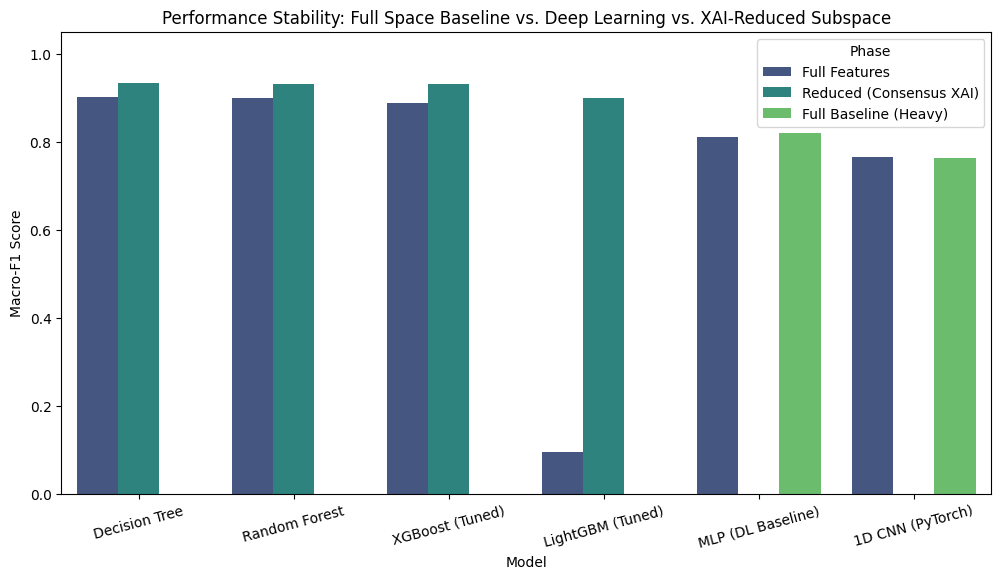

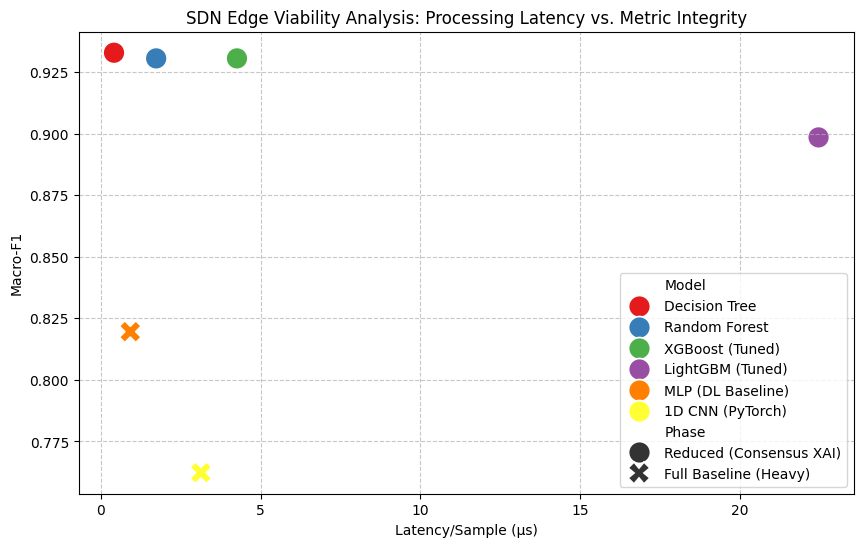


Pipeline execution complete. All constraints satisfied.


In [6]:
test_metrics = []

def benchmark_model(name, model, X_test_df, y_test_arr, phase_name):
    start_infer = time.perf_counter()
    if 'CNN' in name:
        model.eval()
        with torch.no_grad():
            preds_tensor = model(torch.tensor(X_test_df.values, dtype=torch.float32).unsqueeze(1))
            preds = torch.argmax(preds_tensor, dim=1).numpy()
    else:
        preds = model.predict(X_test_df)
    infer_time = time.perf_counter() - start_infer
    
    latency_us = (infer_time / len(X_test_df)) * 1e6
    pps = len(X_test_df) / infer_time
    acc = accuracy_score(y_test_arr, preds)
    f1 = f1_score(y_test_arr, preds, average='macro')
    
    # Model sizing parsing logic
    clean_name = name.replace(' ', '_').replace('(Tuned)', '').strip('_')
    model_path = CONFIG['MODELS_DIR'] / f"{clean_name}_reduced.pkl"
    disk_size_kb = os.path.getsize(model_path) / 1024 if model_path.exists() else 0
    
    test_metrics.append({
        'Model': name,
        'Phase': phase_name,
        'Latency/Sample (µs)': round(latency_us, 2),
        'Throughput (PPS)': int(pps),
        'Accuracy': round(acc, 4),
        'Macro-F1': round(f1, 4),
        'Model Size (KB)': round(disk_size_kb, 1)
    })

print("Initiating strictly isolated benchmarking against Test Split...")

# 1. Benchmark Reduced Feature Space (Proposed Architecture Models)
for name, model in tuned_models.items():
    benchmark_model(name, model, X_test_red, y_test, 'Reduced (Consensus XAI)')

# 2. Benchmark Deep Learning Baselines (Full Feature Space Evaluation for Paper Context)
if 'MLP (DL Baseline)' in global_baseline_models:
    benchmark_model('MLP (DL Baseline)', global_baseline_models['MLP (DL Baseline)'], X_test_scaled, y_test, 'Full Baseline (Heavy)')
if '1D CNN (PyTorch)' in global_baseline_models:
    benchmark_model('1D CNN (PyTorch)', global_baseline_models['1D CNN (PyTorch)'], X_test_scaled, y_test, 'Full Baseline (Heavy)')

test_df = pd.DataFrame(test_metrics)
print("\n--- Final Model Performance & Benchmarks (With DL Baselines Included) ---")
display(test_df)

# Visualization 1: Macro-F1 Comparison Across Framework Stages
plt.figure(figsize=(12, 6))
baseline_comp = baseline_df.copy()
baseline_comp['Model'] = baseline_comp['Model'].replace({'XGBoost': 'XGBoost (Tuned)', 'LightGBM': 'LightGBM (Tuned)'})

compare_df = pd.concat([baseline_comp[['Model', 'Phase', 'Macro-F1']], 
                        test_df[['Model', 'Phase', 'Macro-F1']]]).drop_duplicates()

sns.barplot(data=compare_df, x='Model', y='Macro-F1', hue='Phase', palette='viridis')
plt.title('Performance Stability: Full Space Baseline vs. Deep Learning vs. XAI-Reduced Subspace')
plt.ylim(0.0, 1.05)
plt.ylabel('Macro-F1 Score')
plt.xticks(rotation=15)
plt.savefig(CONFIG['FIGURES_DIR'] / 'f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualization 2: Latency vs. Accuracy Pareto Frontier
plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_df, x='Latency/Sample (µs)', y='Macro-F1', 
                hue='Model', style='Phase', s=250, palette='Set1')
plt.title('SDN Edge Viability Analysis: Processing Latency vs. Metric Integrity')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig(CONFIG['FIGURES_DIR'] / 'latency_pareto.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPipeline execution complete. All constraints satisfied.")